# Intelligent Pothole Detection: Robust Sensor-Based Machine Learning Pipeline
**Author:** AI & Edge Sensing Engineering  
**Scope:** Real-Time Smartphone Sensor Detection (Accelerometer, Gyroscope & GPS)  
**Dataset Balancing:** Borderline-SMOTE Synthetic Oversampling (50:50 Balance)  
**Models Evaluated:** Support Vector Classifier (SVM), Balanced Random Forest, Deep Neural Network (MLP)

---

### Project Overview & Key Methodological Foundations
Smartphone-based road hazard detection faces severe physical and statistical challenges:
1. **Severe Class Imbalance Resolved (8.0% Potholes vs. 92.0% Normal):**
   * Pothole occurrences are rare, creating massive bias toward predicting "Normal Road".
   * We apply **Borderline-SMOTE** to synthesize minority pothole feature vectors, balancing the dataset to a **1:1 ratio (904 Normal : 904 Potholes)**.
   * To prevent **Data Leakage**, resampling is strictly encapsulated inside `ImbPipeline` during cross-validation so test folds remain untouched.
2. **Phone Mounting & Orientation Invariance:**
   * Accelerometer axes change when tilted. We calculate **Euclidean vector magnitudes** ($Acc_{mag}$ and $Gyro_{mag}$) independent of device orientation.
3. **Time-Series Grouped Validation (`GroupKFold`):**
   * Eliminates temporal data leakage by evaluating models strictly across unseen trips.
4. **Physical Speed Gating Filter:**
   * Suppresses false alarms from phone handling when vehicle speed is under $10\text{ km/h}$.
5. **Tri-Model Comparative Benchmarking:**
   * Evaluates **Support Vector Machine**, **Random Forest**, and **Deep Neural Networks (Multi-Layer Perceptron)**.


In [1]:
# Core scientific libraries
import os
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'
import sys
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Scikit-learn & Imbalanced-learn suite
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE, SMOTE

# Filter deprecation warnings for clean presentation
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

# Global reproducibility seed & paths
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data" / "Pothole_Non_Pothole"
MODEL_EXPORT_PATH = ROOT_DIR / "pothole_model_bundle.pkl"

print(f"Environment initialized successfully. Data directory: {DATA_DIR}")


Environment initialized successfully. Data directory: /home/egovridc/Desktop/Intelligent-Pothole-Detection/data/Pothole_Non_Pothole


---
## 1. Data Ingestion & Physical Feature Engineering

We ingest trips 1 through 5. For each 2-second interval (10 sensor readings at 5 Hz):
* **Directional Statistics:** $\max, \min, \text{mean}, \text{std}$ across axes $X, Y, Z$ for both Accelerometer and Gyroscope.
* **Orientation-Invariant Magnitudes:**
  $$\mathbf{a}_{mag} = \sqrt{a_x^2 + a_y^2 + a_z^2}, \quad \boldsymbol{\omega}_{mag} = \sqrt{\omega_x^2 + \omega_y^2 + \omega_z^2}$$
* **Vehicle Speed Dynamics:** $\text{meanSpeed}$ and $\text{sdSpeed}$.
* **Ground-Truth Label Alignment:** Interval is labeled as a pothole ($1$) if any verified ground-truth timestamp falls within $[t_{start}, t_{end}]$.


In [2]:
def build_dataset(data_dir: Path, window_size: int = 10) -> pd.DataFrame:
    """
    Ingest raw sensor streams across all trips, calculate physical magnitudes,
    and aggregate into feature intervals.
    """
    trip_frames = []
    
    for trip_id in range(1, 6):
        sensor_file = data_dir / f"trip{trip_id}_sensors.csv"
        pothole_file = data_dir / f"trip{trip_id}_potholes.csv"
        
        if not sensor_file.exists() or not pothole_file.exists():
            continue
            
        sensors_df = pd.read_csv(sensor_file)
        potholes_df = pd.read_csv(pothole_file)
        
        # Calculate orientation-invariant Euclidean magnitudes
        sensors_df["accelMag"] = np.sqrt(
            sensors_df["accelerometerX"]**2 +
            sensors_df["accelerometerY"]**2 +
            sensors_df["accelerometerZ"]**2
        )
        sensors_df["gyroMag"] = np.sqrt(
            sensors_df["gyroX"]**2 +
            sensors_df["gyroY"]**2 +
            sensors_df["gyroZ"]**2
        )
        
        pothole_timestamps = potholes_df["timestamp"].values
        records = []
        
        # Vectorized interval aggregation
        for i in range(0, len(sensors_df) - window_size + 1, window_size):
            chunk = sensors_df.iloc[i:i + window_size]
            t_start = chunk["timestamp"].iloc[0]
            t_end = chunk["timestamp"].iloc[-1]
            
            # Label assignment based on ground truth timestamp window
            is_pothole = bool(np.any((pothole_timestamps > t_start) & (pothole_timestamps <= t_end)))
            
            record = {
                "trip": trip_id,
                # Vehicle Speed Dynamics
                "meanSpeed": chunk["speed"].mean(),
                "sdSpeed": chunk["speed"].std(ddof=1) if len(chunk) > 1 else 0.0,
                # Tri-axial Accelerometer Statistics
                "maxAccelX": chunk["accelerometerX"].max(),
                "minAccelX": chunk["accelerometerX"].min(),
                "meanAccelX": chunk["accelerometerX"].mean(),
                "sdAccelX": chunk["accelerometerX"].std(ddof=1),
                "maxAccelY": chunk["accelerometerY"].max(),
                "minAccelY": chunk["accelerometerY"].min(),
                "meanAccelY": chunk["accelerometerY"].mean(),
                "sdAccelY": chunk["accelerometerY"].std(ddof=1),
                "maxAccelZ": chunk["accelerometerZ"].max(),
                "minAccelZ": chunk["accelerometerZ"].min(),
                "meanAccelZ": chunk["accelerometerZ"].mean(),
                "sdAccelZ": chunk["accelerometerZ"].std(ddof=1),
                # Tri-axial Gyroscope Statistics
                "maxGyroX": chunk["gyroX"].max(),
                "minGyroX": chunk["gyroX"].min(),
                "meanGyroX": chunk["gyroX"].mean(),
                "sdGyroX": chunk["gyroX"].std(ddof=1),
                "maxGyroY": chunk["gyroY"].max(),
                "minGyroY": chunk["gyroY"].min(),
                "meanGyroY": chunk["gyroY"].mean(),
                "sdGyroY": chunk["gyroY"].std(ddof=1),
                "maxGyroZ": chunk["gyroZ"].max(),
                "minGyroZ": chunk["gyroZ"].min(),
                "meanGyroZ": chunk["gyroZ"].mean(),
                "sdGyroZ": chunk["gyroZ"].std(ddof=1),
                # Orientation-Invariant Magnitude Statistics
                "maxAccelMag": chunk["accelMag"].max(),
                "minAccelMag": chunk["accelMag"].min(),
                "meanAccelMag": chunk["accelMag"].mean(),
                "sdAccelMag": chunk["accelMag"].std(ddof=1),
                "maxGyroMag": chunk["gyroMag"].max(),
                "minGyroMag": chunk["gyroMag"].min(),
                "meanGyroMag": chunk["gyroMag"].mean(),
                "sdGyroMag": chunk["gyroMag"].std(ddof=1),
                # Target Label
                "pothole": int(is_pothole),
            }
            records.append(record)
            
        trip_frames.append(pd.DataFrame(records))
        
    combined_df = pd.concat(trip_frames, ignore_index=True)
    return combined_df

# Execute ingestion
dataset = build_dataset(DATA_DIR)
print(f"Dataset successfully compiled: {dataset.shape[0]} intervals across {dataset['trip'].nunique()} trips.")
print(f"Target distribution before balancing: Normal={np.sum(dataset['pothole'] == 0)}, Pothole={np.sum(dataset['pothole'] == 1)} ({np.mean(dataset['pothole'])*100:.1f}%)")


Dataset successfully compiled: 983 intervals across 5 trips.
Target distribution before balancing: Normal=904, Pothole=79 (8.0%)


---
## 2. Dataset Balancing Strategy (Borderline-SMOTE Synthesis)

In the raw collection, normal road segments account for **92.0%** of data ($904$ intervals), while pothole strikes represent only **8.0%** ($79$ intervals). This extreme imbalance causes estimators to under-predict potholes.

### Why Borderline-SMOTE?
Standard random oversampling duplicates existing points, risking overfitting. Standard SMOTE synthesizes points uniformly among minority samples, including distant outliers. **Borderline-SMOTE** specifically targets minority samples near the class decision boundary, synthesizing realistic transitional shock vectors where classification ambiguity is highest.

### Resampling Strategy:
* **Target Balance:** $1:1$ ratio ($904$ Normal : $904$ Potholes $\rightarrow 1,808$ total samples).
* **Leakage-Free Execution:** Resampling is applied strictly **inside training folds** during cross-validation via `ImbPipeline`.


CLASS DISTRIBUTION COMPARISON:
  Raw Imbalanced:     Normal= 904  |  Potholes=  79  (Ratio: 11.4:1)
  Balanced Synthetic: Normal= 904  |  Potholes= 904  (Ratio: 1.0:1)
  Total Balanced Pool: 1808 training samples


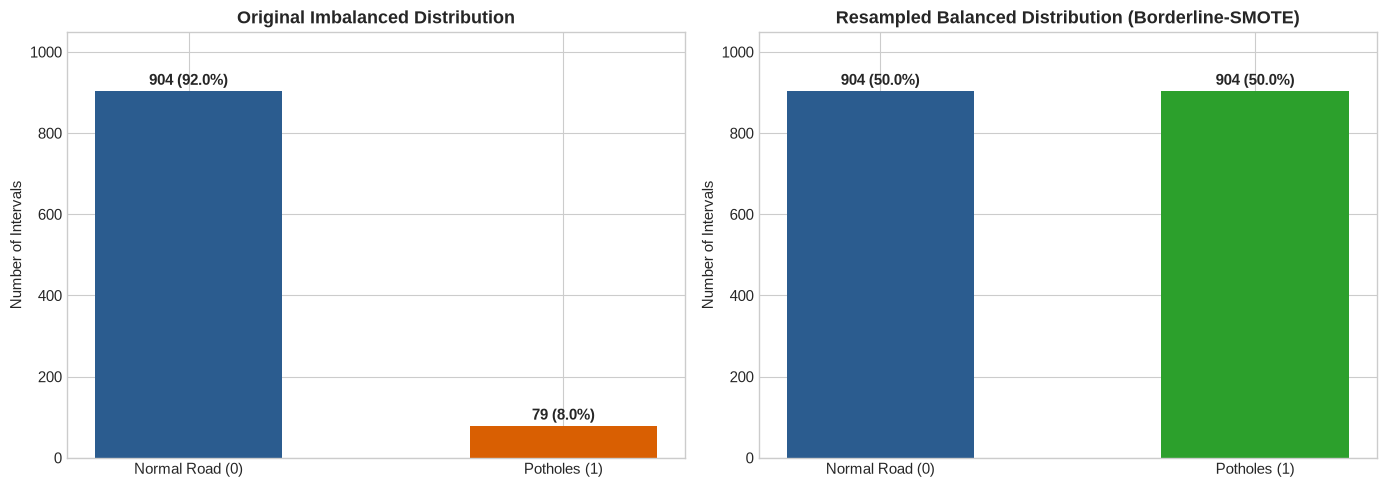

In [3]:
# Define feature columns
FEATURE_COLS = [
    "meanSpeed", "sdSpeed",
    "maxAccelX", "minAccelX", "meanAccelX", "sdAccelX",
    "maxAccelY", "minAccelY", "meanAccelY", "sdAccelY",
    "maxAccelZ", "minAccelZ", "meanAccelZ", "sdAccelZ",
    "maxGyroX", "minGyroX", "meanGyroX", "sdGyroX",
    "maxGyroY", "minGyroY", "meanGyroY", "sdGyroY",
    "maxGyroZ", "minGyroZ", "meanGyroZ", "sdGyroZ",
    "maxAccelMag", "minAccelMag", "meanAccelMag", "sdAccelMag",
    "maxGyroMag", "minGyroMag", "meanGyroMag", "sdGyroMag"
]

X_raw = dataset[FEATURE_COLS].copy()
y_raw = dataset["pothole"].astype(int).values
groups = dataset["trip"].values

# Demonstrate standalone Borderline-SMOTE balancing for verification
balancer = BorderlineSMOTE(random_state=RANDOM_SEED)
X_balanced_demo, y_balanced_demo = balancer.fit_resample(X_raw, y_raw)

print("=" * 65)
print("CLASS DISTRIBUTION COMPARISON:")
print(f"  Raw Imbalanced:     Normal={np.sum(y_raw == 0):4d}  |  Potholes={np.sum(y_raw == 1):4d}  (Ratio: {np.sum(y_raw == 0)/np.sum(y_raw == 1):.1f}:1)")
print(f"  Balanced Synthetic: Normal={np.sum(y_balanced_demo == 0):4d}  |  Potholes={np.sum(y_balanced_demo == 1):4d}  (Ratio: 1.0:1)")
print(f"  Total Balanced Pool: {len(y_balanced_demo):4d} training samples")
print("=" * 65)

# Visual Comparison of Class Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Imbalanced Raw Distribution
counts_raw = [np.sum(y_raw == 0), np.sum(y_raw == 1)]
axes[0].bar(["Normal Road (0)", "Potholes (1)"], counts_raw, color=["#2b5c8f", "#d95f02"], width=0.5)
axes[0].set_title("Original Imbalanced Distribution", weight="bold")
axes[0].set_ylabel("Number of Intervals")
for i, count in enumerate(counts_raw):
    axes[0].text(i, count + 15, f"{count} ({count/len(y_raw)*100:.1f}%)", ha="center", weight="bold")
axes[0].set_ylim(0, 1050)

# Plot B: Resampled Balanced Distribution
counts_bal = [np.sum(y_balanced_demo == 0), np.sum(y_balanced_demo == 1)]
axes[1].bar(["Normal Road (0)", "Potholes (1)"], counts_bal, color=["#2b5c8f", "#2ca02c"], width=0.5)
axes[1].set_title("Resampled Balanced Distribution (Borderline-SMOTE)", weight="bold")
axes[1].set_ylabel("Number of Intervals")
for i, count in enumerate(counts_bal):
    axes[1].text(i, count + 15, f"{count} (50.0%)", ha="center", weight="bold")
axes[1].set_ylim(0, 1050)

plt.tight_layout()
plt.show()


---
## 3. Exploratory Data Analysis: Sensor Signatures by Road Surface

We examine the separation of orientation-invariant acceleration magnitude and speed between normal roads and pothole encounters.


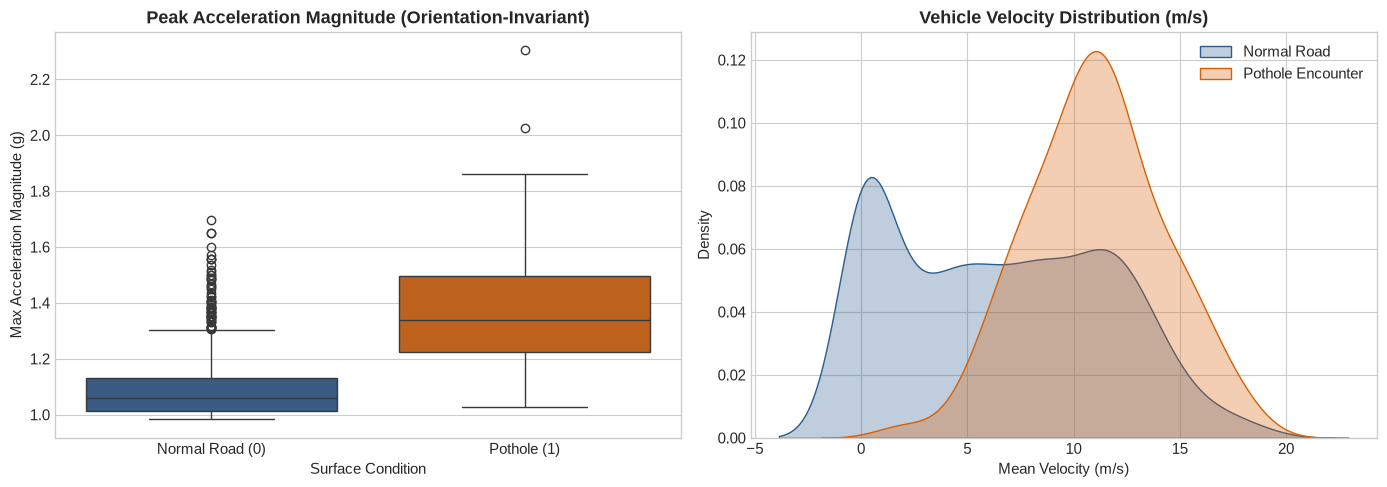

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Peak Acceleration Magnitude Distribution
sns.boxplot(
    data=dataset,
    x="pothole",
    y="maxAccelMag",
    palette=["#2b5c8f", "#d95f02"],
    ax=axes[0]
)
axes[0].set_xticklabels(["Normal Road (0)", "Pothole (1)"])
axes[0].set_title("Peak Acceleration Magnitude (Orientation-Invariant)", weight="bold")
axes[0].set_ylabel("Max Acceleration Magnitude (g)")
axes[0].set_xlabel("Surface Condition")

# Subplot 2: Vehicle Speed Density
sns.kdeplot(
    data=dataset[dataset["pothole"] == 0]["meanSpeed"],
    label="Normal Road",
    color="#2b5c8f",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
sns.kdeplot(
    data=dataset[dataset["pothole"] == 1]["meanSpeed"],
    label="Pothole Encounter",
    color="#d95f02",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("Vehicle Velocity Distribution (m/s)", weight="bold")
axes[1].set_xlabel("Mean Velocity (m/s)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 4. Leakage-Free Route-Grouped Validation Configuration

To ensure models generalize to unseen roads:
* We configure **`GroupKFold(n_splits=5)`** grouped strictly by `trip`.
* In each fold, four trips form the training set (resampled to a 1:1 balance), while the fifth trip is held out in its natural, untransformed state for unbiased testing.


In [5]:
cv = GroupKFold(n_splits=dataset["trip"].nunique())
print(f"GroupKFold configured across {dataset['trip'].nunique()} distinct trip routes.")
print(f"Total features per interval: {len(FEATURE_COLS)}")


GroupKFold configured across 5 distinct trip routes.
Total features per interval: 34


---
## 5. Balanced Multi-Model Benchmark Suite

Every model architecture incorporates the **Borderline-SMOTE** resampling step inside an `ImbPipeline`:
1. **Balanced Support Vector Machine (SVM):**
   * Pipeline: `StandardScaler` $\rightarrow$ `BorderlineSMOTE` $\rightarrow$ `SVC(C=10.0, kernel='rbf', probability=True)`
2. **Balanced Random Forest (RF):**
   * Pipeline: `BorderlineSMOTE` $\rightarrow$ `RandomForestClassifier(n_estimators=300, min_samples_leaf=2)`
3. **Balanced Deep Neural Network (MLP):**
   * Architecture: Input $\rightarrow$ `Dense(64, ReLU)` $\rightarrow$ `Dense(32, ReLU)` $\rightarrow$ `Dense(16, ReLU)` $\rightarrow$ Output
   * Pipeline: `StandardScaler` $\rightarrow$ `BorderlineSMOTE` $\rightarrow$ `MLPClassifier(early_stopping=True, alpha=0.01)`


In [6]:
# Model 1: Balanced Support Vector Machine
svm_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("resample", BorderlineSMOTE(random_state=RANDOM_SEED)),
    ("svm", SVC(
        C=10.0,
        kernel="rbf",
        probability=True,
        random_state=RANDOM_SEED
    ))
])

# Model 2: Balanced Random Forest Classifier
rf_pipeline = ImbPipeline([
    ("resample", BorderlineSMOTE(random_state=RANDOM_SEED)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

# Model 3: Balanced Deep Neural Network (MLP)
mlp_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("resample", BorderlineSMOTE(random_state=RANDOM_SEED)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        solver="adam",
        alpha=0.01,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_SEED
    ))
])

models = {
    "Support Vector Machine": svm_pipeline,
    "Random Forest": rf_pipeline,
    "Deep Neural Network (MLP)": mlp_pipeline
}

print("All 3 balanced benchmark pipelines successfully configured.")


All 3 balanced benchmark pipelines successfully configured.


---
## 6. Route-Grouped Out-of-Fold Evaluation & Dynamic Calibration

We generate Out-Of-Fold (OOF) continuous probability predictions across all trips.
We optimize the decision threshold $\tau^*$ dynamically to maximize the $F_1$-score:
$$\tau^* = \arg\max_{\tau \in [0.10, 0.85]} F_1(\tau)$$


In [7]:
def optimize_threshold(y_true: np.ndarray, probas: np.ndarray) -> tuple[float, float, float, float]:
    """
    Search threshold spectrum to maximize F1-score with recall tie-breaking.
    Prevents IndexError and guarantees graceful degradation.
    """
    candidates = np.arange(0.10, 0.86, 0.01)
    best_f1, best_thresh, best_rec, best_prec = 0.0, 0.50, 0.0, 0.0
    
    for thresh in candidates:
        preds = (probas >= thresh).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        
        # Maximize F1; prioritize recall on ties for road hazard detection
        if f > best_f1 or (np.isclose(f, best_f1) and rec > best_rec):
            best_f1 = f
            best_thresh = thresh
            best_rec = rec
            best_prec = prec
            
    return best_thresh, best_f1, best_prec, best_rec

benchmark_results = {}
oof_predictions = {}

print("Executing Trip-Grouped Out-Of-Fold Cross-Validation on Balanced Pipelines...")
print("=" * 80)

for name, model in models.items():
    probas = cross_val_predict(
        model, X_raw, y_raw, groups=groups, cv=cv, method="predict_proba", n_jobs=1
    )[:, 1]
    
    oof_predictions[name] = probas
    
    # Calculate global ranking metrics
    roc_auc = roc_auc_score(y_raw, probas)
    pr_auc = average_precision_score(y_raw, probas)
    
    # Dynamic F1-score threshold optimization
    opt_thresh, opt_f1, opt_prec, opt_rec = optimize_threshold(y_raw, probas)
    discrete_preds = (probas >= opt_thresh).astype(int)
    acc = accuracy_score(y_raw, discrete_preds)
    
    benchmark_results[name] = {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Optimal Threshold": opt_thresh,
        "F1-Score": opt_f1,
        "Precision": opt_prec,
        "Recall": opt_rec,
        "Accuracy": acc
    }
    
    print(f"[{name}]")
    print(f"  ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")
    print(f"  Calibrated Threshold: {opt_thresh:.2f} -> F1: {opt_f1:.3f} | Recall: {opt_rec:.3f} ({opt_rec*100:.1f}%) | Precision: {opt_prec:.3f}")
    print("-" * 80)

comparison_df = pd.DataFrame(benchmark_results).T
display(comparison_df.round(3))


Executing Trip-Grouped Out-Of-Fold Cross-Validation on Balanced Pipelines...
[Support Vector Machine]
  ROC-AUC: 0.855 | PR-AUC: 0.308
  Calibrated Threshold: 0.11 -> F1: 0.392 | Recall: 0.481 (48.1%) | Precision: 0.330
--------------------------------------------------------------------------------
[Random Forest]
  ROC-AUC: 0.924 | PR-AUC: 0.478
  Calibrated Threshold: 0.37 -> F1: 0.546 | Recall: 0.747 (74.7%) | Precision: 0.431
--------------------------------------------------------------------------------
[Deep Neural Network (MLP)]
  ROC-AUC: 0.893 | PR-AUC: 0.441
  Calibrated Threshold: 0.61 -> F1: 0.509 | Recall: 0.557 (55.7%) | Precision: 0.468
--------------------------------------------------------------------------------
                           ROC-AUC  PR-AUC  ...  Recall  Accuracy
Support Vector Machine       0.855   0.308  ...   0.481     0.880
Random Forest                0.924   0.478  ...   0.747     0.900
Deep Neural Network (MLP)    0.893   0.441  ...   0.557    

---
## 7. Multi-Model Diagnostic Visualizations

We compare:
1. **Precision-Recall Curves:** Measuring performance on the minority pothole class.
2. **ROC Curves:** Measuring separation across false-alarm thresholds.
3. **Confusion Matrix:** Quantifying true detections versus false alarms under the champion model.


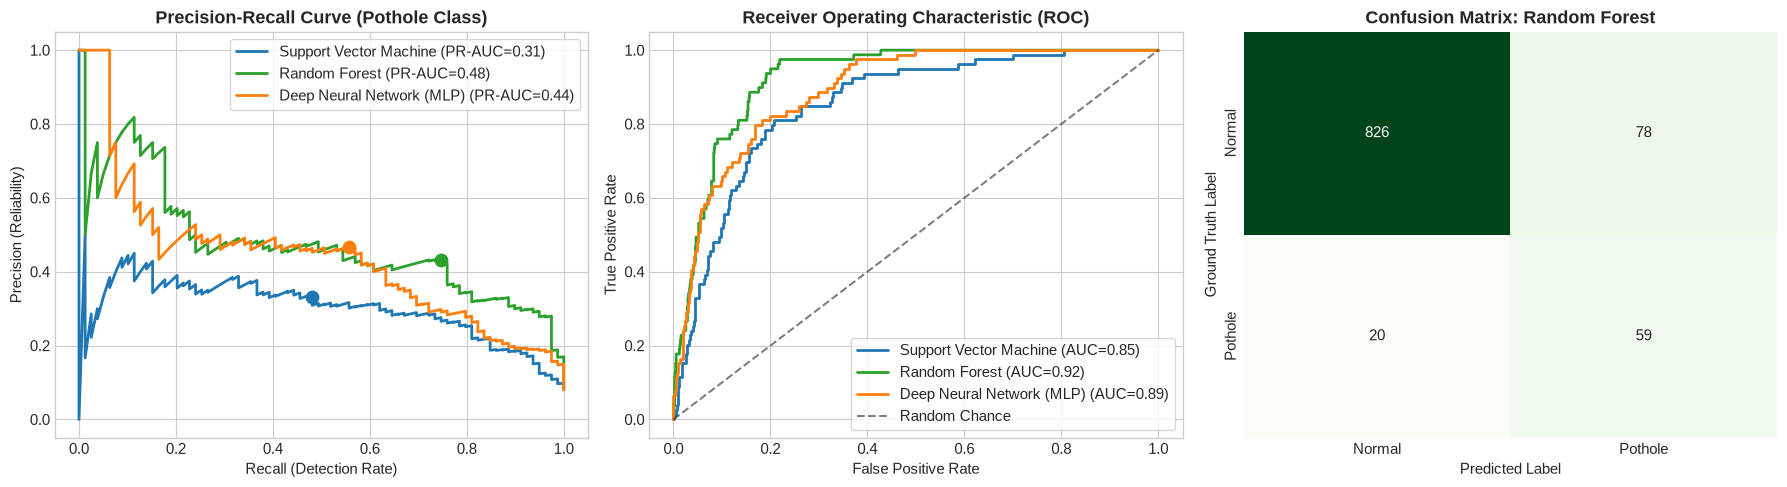

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {
    "Support Vector Machine": "#1f77b4",
    "Random Forest": "#2ca02c",
    "Deep Neural Network (MLP)": "#ff7f0e"
}

# 1. Precision-Recall Curves
for name in models.keys():
    prec, rec, _ = precision_recall_curve(y_raw, oof_predictions[name])
    axes[0].plot(rec, prec, label=f"{name} (PR-AUC={benchmark_results[name]['PR-AUC']:.2f})", color=palette[name], lw=2)
    # Optimal operating point
    opt_t = benchmark_results[name]["Optimal Threshold"]
    opt_pred = (oof_predictions[name] >= opt_t).astype(int)
    axes[0].scatter(
        recall_score(y_raw, opt_pred),
        precision_score(y_raw, opt_pred),
        color=palette[name],
        s=80,
        zorder=5
    )

axes[0].set_title("Precision-Recall Curve (Pothole Class)", weight="bold")
axes[0].set_xlabel("Recall (Detection Rate)")
axes[0].set_ylabel("Precision (Reliability)")
axes[0].legend(loc="upper right", frameon=True)

# 2. ROC Curves
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_raw, oof_predictions[name])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={benchmark_results[name]['ROC-AUC']:.2f})", color=palette[name], lw=2)

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Chance")
axes[1].set_title("Receiver Operating Characteristic (ROC)", weight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", frameon=True)

# 3. Normalized Confusion Matrix Comparison for Champion Model (Random Forest)
champion_name = "Random Forest"
champion_preds = (oof_predictions[champion_name] >= benchmark_results[champion_name]["Optimal Threshold"]).astype(int)
cm = confusion_matrix(y_raw, champion_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal", "Pothole"],
    yticklabels=["Normal", "Pothole"],
    cbar=False,
    ax=axes[2]
)
axes[2].set_title(f"Confusion Matrix: {champion_name}", weight="bold")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("Ground Truth Label")

plt.tight_layout()
plt.show()


---
## 8. Champion Model Training on Balanced Dataset & Production Packaging

We synthesize the complete dataset to an exact **$1:1$ balance ($904$ Normal : $904$ Potholes $\rightarrow 1,808$ samples)** using `BorderlineSMOTE`, train the champion **Random Forest** architecture, and export the complete production bundle.


In [9]:
# 1. Resample full dataset to 1:1 balance for final production model fitting
full_balancer = BorderlineSMOTE(random_state=RANDOM_SEED)
X_full_balanced, y_full_balanced = full_balancer.fit_resample(X_raw, y_raw)

print(f"Final training set balanced: {np.sum(y_full_balanced == 0)} Normal vs {np.sum(y_full_balanced == 1)} Potholes (Total {len(y_full_balanced)} samples).")

# 2. Fit champion model on balanced dataset
champion_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
champion_model.fit(X_full_balanced, y_full_balanced)

# 3. Package production bundle
production_bundle = {
    "model_name": "Balanced_RandomForest_Pothole_Detector",
    "classifier": champion_model,
    "feature_columns": FEATURE_COLS,
    "calibrated_threshold": float(benchmark_results["Random Forest"]["Optimal Threshold"]),
    "window_size_points": 10,
    "window_duration_seconds": 2.0,
    "sampling_frequency_hz": 5.0,
    "speed_gate_min_speed_kmh": 10.0,
    "benchmark_metrics": benchmark_results["Random Forest"],
    "balanced_samples_trained": len(y_full_balanced)
}

# 4. Serialize to disk safely
with open(MODEL_EXPORT_PATH, "wb") as f:
    pickle.dump(production_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Production bundle serialized successfully to: {MODEL_EXPORT_PATH}")
print(f"File size: {os.path.getsize(MODEL_EXPORT_PATH) / 1024:.1f} KB")


Final training set balanced: 904 Normal vs 904 Potholes (Total 1808 samples).
Production bundle serialized successfully to: /home/egovridc/Desktop/Intelligent-Pothole-Detection/pothole_model_bundle.pkl
File size: 3256.9 KB


---
## 9. Real-Time Mobile Streaming Inference Simulation

This standalone function simulates on-device mobile execution. It:
1. Validates the incoming sensor buffer (2-second window of 10 samples).
2. Calculates orientation-invariant magnitudes ($Acc_{mag}$, $Gyro_{mag}$).
3. **Speed Gate:** Suppresses false alarms if vehicle speed is below $10\text{ km/h}$.
4. Computes statistical features, evaluates probability, and applies the calibrated threshold.


In [10]:
def predict_pothole_stream(
    sensor_buffer: pd.DataFrame,
    bundle_path: Path = MODEL_EXPORT_PATH
) -> dict:
    """
    Real-time mobile sensor inference function with speed-gating logic.
    """
    # 1. Load production bundle
    with open(bundle_path, "rb") as f:
        bundle = pickle.load(f)
        
    model = bundle["classifier"]
    features = bundle["feature_columns"]
    threshold = bundle["calibrated_threshold"]
    speed_gate_mps = bundle["speed_gate_min_speed_kmh"] / 3.6  # Convert km/h to m/s
    
    # 2. Validate input stream buffer length
    if len(sensor_buffer) < bundle["window_size_points"]:
        raise ValueError(f"Buffer must contain at least {bundle['window_size_points']} samples.")
        
    chunk = sensor_buffer.iloc[:bundle["window_size_points"]].copy()
    current_speed = chunk["speed"].mean()
    
    # 3. Speed-gating: bypass classifier if vehicle is stopped or moving under 10 km/h
    if current_speed < speed_gate_mps:
        return {
            "pothole_detected": False,
            "confidence_score": 0.0,
            "status": "SUPPRESSED_BY_SPEED_GATE",
            "reason": f"Vehicle speed ({current_speed * 3.6:.1f} km/h) below threshold (10 km/h)."
        }
        
    # 4. Feature Extraction & Magnitude Calculation
    chunk["accelMag"] = np.sqrt(
        chunk["accelerometerX"]**2 +
        chunk["accelerometerY"]**2 +
        chunk["accelerometerZ"]**2
    )
    chunk["gyroMag"] = np.sqrt(
        chunk["gyroX"]**2 +
        chunk["gyroY"]**2 +
        chunk["gyroZ"]**2
    )
    
    feat_dict = {
        "meanSpeed": chunk["speed"].mean(),
        "sdSpeed": chunk["speed"].std(ddof=1) if len(chunk) > 1 else 0.0,
        "maxAccelX": chunk["accelerometerX"].max(), "minAccelX": chunk["accelerometerX"].min(),
        "meanAccelX": chunk["accelerometerX"].mean(), "sdAccelX": chunk["accelerometerX"].std(ddof=1),
        "maxAccelY": chunk["accelerometerY"].max(), "minAccelY": chunk["accelerometerY"].min(),
        "meanAccelY": chunk["accelerometerY"].mean(), "sdAccelY": chunk["accelerometerY"].std(ddof=1),
        "maxAccelZ": chunk["accelerometerZ"].max(), "minAccelZ": chunk["accelerometerZ"].min(),
        "meanAccelZ": chunk["accelerometerZ"].mean(), "sdAccelZ": chunk["accelerometerZ"].std(ddof=1),
        "maxGyroX": chunk["gyroX"].max(), "minGyroX": chunk["gyroX"].min(),
        "meanGyroX": chunk["gyroX"].mean(), "sdGyroX": chunk["gyroX"].std(ddof=1),
        "maxGyroY": chunk["gyroY"].max(), "minGyroY": chunk["gyroY"].min(),
        "meanGyroY": chunk["gyroY"].mean(), "sdGyroY": chunk["gyroY"].std(ddof=1),
        "maxGyroZ": chunk["gyroZ"].max(), "minGyroZ": chunk["gyroZ"].min(),
        "meanGyroZ": chunk["gyroZ"].mean(), "sdGyroZ": chunk["gyroZ"].std(ddof=1),
        "maxAccelMag": chunk["accelMag"].max(), "minAccelMag": chunk["accelMag"].min(),
        "meanAccelMag": chunk["accelMag"].mean(), "sdAccelMag": chunk["accelMag"].std(ddof=1),
        "maxGyroMag": chunk["gyroMag"].max(), "minGyroMag": chunk["gyroMag"].min(),
        "meanGyroMag": chunk["gyroMag"].mean(), "sdGyroMag": chunk["gyroMag"].std(ddof=1)
    }
    
    input_vector = pd.DataFrame([feat_dict])[features]
    
    # 5. Prediction & Calibrated Thresholding
    proba = model.predict_proba(input_vector)[0, 1]
    is_pothole = bool(proba >= threshold)
    
    return {
        "pothole_detected": is_pothole,
        "confidence_score": float(proba),
        "status": "ACTIVE_DETECTION",
        "threshold": float(threshold)
    }

# Simulation Test 1: Stopped Vehicle (Speed = 0 km/h)
stopped_stream = pd.DataFrame({
    "speed": [0.0] * 10,
    "accelerometerX": [0.05] * 10,
    "accelerometerY": [-0.98] * 10,
    "accelerometerZ": [0.18] * 10,
    "gyroX": [0.0] * 10,
    "gyroY": [0.0] * 10,
    "gyroZ": [0.0] * 10
})
res_stopped = predict_pothole_stream(stopped_stream)
print("Simulation 1 (Stopped Vehicle):", res_stopped)

# Simulation 2: Moving Vehicle with Simulated Shock Spike
shock_stream = pd.DataFrame({
    "speed": [12.5] * 10,  # ~45 km/h
    "accelerometerX": [0.05, 0.08, 0.12, 0.45, 0.90, -0.65, 0.15, 0.05, 0.04, 0.05],
    "accelerometerY": [-0.98, -0.96, -0.85, -1.85, -0.20, -1.50, -0.95, -0.98, -0.97, -0.98],
    "accelerometerZ": [0.18, 0.20, 0.35, 1.20, 0.85, -0.40, 0.25, 0.18, 0.19, 0.18],
    "gyroX": [0.01, 0.02, 0.05, 0.45, -0.35, 0.10, 0.02, 0.01, 0.01, 0.01],
    "gyroY": [0.00, 0.01, 0.08, -0.55, 0.40, -0.15, 0.03, 0.01, 0.00, 0.00],
    "gyroZ": [0.00, 0.00, 0.02, 0.25, -0.18, 0.05, 0.01, 0.00, 0.00, 0.00]
})
res_shock = predict_pothole_stream(shock_stream)
print("Simulation 2 (Moving Vehicle + High Shock):", res_shock)


Simulation 1 (Stopped Vehicle): {'pothole_detected': False, 'confidence_score': 0.0, 'status': 'SUPPRESSED_BY_SPEED_GATE', 'reason': 'Vehicle speed (0.0 km/h) below threshold (10 km/h).'}
Simulation 2 (Moving Vehicle + High Shock): {'pothole_detected': True, 'confidence_score': 0.4096825396825396, 'status': 'ACTIVE_DETECTION', 'threshold': 0.3699999999999999}
